# Data Pre-processing Techniques


In [67]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


1. Feature Scaling

In [68]:
x1=np.random.randint(1,20,size=(20,1))
x2=np.random.randint(10,200,size=(20,1))
x3=np.random.randint(100,2000,size=(20,1))
X=np.concatenate((x1,x2,x3),axis=1)
X

array([[  12,   98, 1647],
       [  17,   58, 1415],
       [  19,   24, 1067],
       [  18,  126,  284],
       [  19,  141,  925],
       [   6,  184,  900],
       [   2,  184,  970],
       [   3,  196,  155],
       [  16,  123, 1972],
       [  19,   12,  915],
       [  18,  111,  960],
       [  11,  129, 1822],
       [   3,   93,  219],
       [  16,   50,  648],
       [   4,   57, 1470],
       [   6,   99,  140],
       [  19,   49, 1643],
       [   2,   50, 1288],
       [   6,  100, 1336],
       [  14,   23,  738]], dtype=int32)

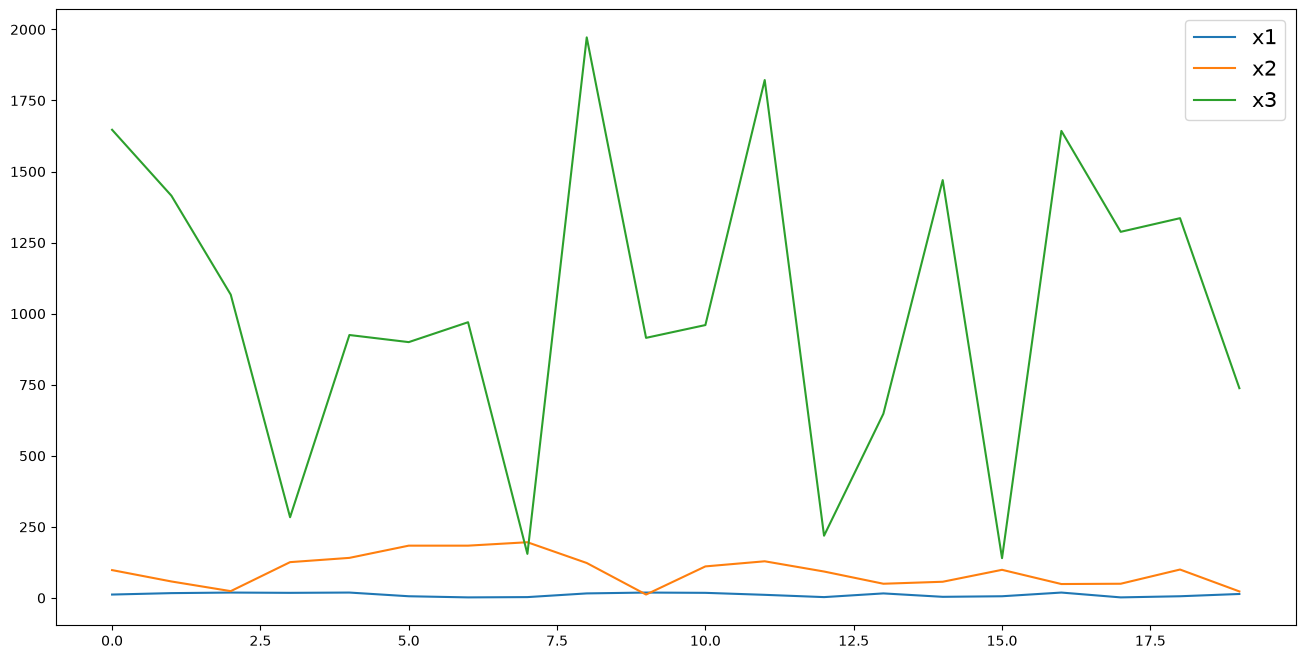

In [69]:
plt.figure(figsize=(16,8))
plt.plot(x1)
plt.plot(x2)
plt.plot(x3)
plt.legend(['x1','x2','x3'],fontsize=15)
plt.show()

In [70]:
X.mean(axis=0)

array([  11.5 ,   95.35, 1025.7 ])

In [71]:
X.mean(axis=1)

array([585.66666667, 496.66666667, 370.        , 142.66666667,
       361.66666667, 363.33333333, 385.33333333, 118.        ,
       703.66666667, 315.33333333, 363.        , 654.        ,
       105.        , 238.        , 510.33333333,  81.66666667,
       570.33333333, 446.66666667, 480.66666667, 258.33333333])

In [72]:
X.std(axis=0)

array([  6.55362495,  53.60062966, 539.76430968])

## 1. Normalization ##

In [73]:
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler()
mm.fit(X)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](3,)","[ 19., 196.,1972.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](3,)","[ 2., 12.,140.]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](3,)","[ 17., 184.,1832.]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](3,)","[-0.12,-0.07,-0.08]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,20
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](3,)","[0.06,0.01,0. ]"


In [74]:
X_norm=mm.transform(X)
X_norm

array([[0.58823529, 0.4673913 , 0.82259825],
       [0.88235294, 0.25      , 0.6959607 ],
       [1.        , 0.06521739, 0.50600437],
       [0.94117647, 0.61956522, 0.07860262],
       [1.        , 0.70108696, 0.42849345],
       [0.23529412, 0.93478261, 0.41484716],
       [0.        , 0.93478261, 0.45305677],
       [0.05882353, 1.        , 0.00818777],
       [0.82352941, 0.60326087, 1.        ],
       [1.        , 0.        , 0.42303493],
       [0.94117647, 0.53804348, 0.44759825],
       [0.52941176, 0.63586957, 0.91812227],
       [0.05882353, 0.44021739, 0.04312227],
       [0.82352941, 0.20652174, 0.27729258],
       [0.11764706, 0.24456522, 0.72598253],
       [0.23529412, 0.47282609, 0.        ],
       [1.        , 0.20108696, 0.82041485],
       [0.        , 0.20652174, 0.62663755],
       [0.23529412, 0.47826087, 0.65283843],
       [0.70588235, 0.05978261, 0.32641921]])

In [75]:
X_norm.mean(axis=0)

array([0.55882353, 0.45298913, 0.4834607 ])

In [76]:
X_norm.mean(axis=1)

array([0.62607495, 0.60943788, 0.52374059, 0.5464481 , 0.70986014,
       0.52830796, 0.46261313, 0.35567043, 0.80893009, 0.47434498,
       0.64227273, 0.69446787, 0.18072106, 0.43578124, 0.3627316 ,
       0.23604007, 0.67383393, 0.27771976, 0.45546447, 0.36402806])

# 2. Standardization

In [77]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(X)

StandardScaler()

In [78]:
X_standardized=ss.transform(X)
X_standardized

array([[ 0.07629365,  0.04943972,  1.15105795],
       [ 0.8392302 , -0.69682017,  0.72124072],
       [ 1.14440482, -1.33114108,  0.07651488],
       [ 0.99181751,  0.57182164, -1.37411827],
       [ 1.14440482,  0.8516691 , -0.18656291],
       [-0.8392302 ,  1.65389848, -0.23287942],
       [-1.44957944,  1.65389848, -0.10319319],
       [-1.29699213,  1.87777645, -1.61311147],
       [ 0.68664289,  0.51585215,  1.7531726 ],
       [ 1.14440482, -1.55501905, -0.20508951],
       [ 0.99181751,  0.29197418, -0.12171979],
       [-0.07629365,  0.62779113,  1.47527353],
       [-1.29699213, -0.04384277, -1.4945412 ],
       [ 0.68664289, -0.84607215, -0.69974986],
       [-1.14440482, -0.71547667,  0.82313705],
       [-0.8392302 ,  0.06809621, -1.64090138],
       [ 1.14440482, -0.86472865,  1.14364731],
       [-1.44957944, -0.84607215,  0.48595284],
       [-0.8392302 ,  0.08675271,  0.57488054],
       [ 0.38146827, -1.34979758, -0.53301042]])

In [79]:
X_standardized.mean(axis=0)

array([-1.11022302e-17,  7.77156117e-17, -8.88178420e-17])

In [80]:
X_standardized.mean()

np.float64(-1.850371707708594e-17)

# 2. Data Imputation

In [81]:
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(missing_values=-1 , strategy='mean')


In [82]:
X1=np.array([[1,2,3],[6,0,-1],[3,-1,4]])
X1

array([[ 1,  2,  3],
       [ 6,  0, -1],
       [ 3, -1,  4]])

In [83]:
imputer=imputer.fit(X1)

In [84]:
X1_imputed=imputer.transform(X1)
X1_imputed

array([[1. , 2. , 3. ],
       [6. , 0. , 3.5],
       [3. , 1. , 4. ]])

In [85]:
X2 = np.array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, np.nan],
       ['France', 35.0, 58000.0],
       ['Spain', np.nan, 52000.0],
       ['France', 48.0, 79000.0],
       ['Germany', 50.0, 83000.0],
       ['France', 37.0, 67000.0]])
X2

array([['France', '44.0', '72000.0'],
       ['Spain', '27.0', '48000.0'],
       ['Germany', '30.0', '54000.0'],
       ['Spain', '38.0', '61000.0'],
       ['Germany', '40.0', 'nan'],
       ['France', '35.0', '58000.0'],
       ['Spain', 'nan', '52000.0'],
       ['France', '48.0', '79000.0'],
       ['Germany', '50.0', '83000.0'],
       ['France', '37.0', '67000.0']], dtype='<U32')

In [86]:
imputer2=SimpleImputer(missing_values=np.nan, strategy='mean')
imputer2=imputer2.fit(X2[:,1:3])

In [87]:
X2[:,1:3]=imputer2.transform(X2[:,1:3])

In [88]:
X2

array([['France', '44.0', '72000.0'],
       ['Spain', '27.0', '48000.0'],
       ['Germany', '30.0', '54000.0'],
       ['Spain', '38.0', '61000.0'],
       ['Germany', '40.0', '63777.77777777778'],
       ['France', '35.0', '58000.0'],
       ['Spain', '38.77777777777778', '52000.0'],
       ['France', '48.0', '79000.0'],
       ['Germany', '50.0', '83000.0'],
       ['France', '37.0', '67000.0']], dtype='<U32')

Another Example

In [89]:
X3 = np.array([[46, 'F', 'US'], [65, 'M', 'Canada'], [35, 'F','India'], [-2, 'M', 'Australia'], [49, 'M', 'Netherlands'], [-2, 'F', 'South Africa']])
X3

array([['46', 'F', 'US'],
       ['65', 'M', 'Canada'],
       ['35', 'F', 'India'],
       ['-2', 'M', 'Australia'],
       ['49', 'M', 'Netherlands'],
       ['-2', 'F', 'South Africa']], dtype='<U21')

In [90]:
imputer3=SimpleImputer(missing_values=-2 , strategy='mean')
imputer3=imputer3.fit(X3[:,0].reshape(-1,1))

In [91]:
X3[:,0:1] =imputer3.transform(X3[:,0].reshape(-1,1))

3. Handling Categorical Features 

One Hot Encoding

In [92]:
from sklearn.preprocessing import OneHotEncoder

In [93]:
X_cat=np.array([['red'],['green'],['blue']])
X_cat

array([['red'],
       ['green'],
       ['blue']], dtype='<U5')

In [94]:
ohe = OneHotEncoder(sparse_output=False)
encoded_X_cat=ohe.fit_transform(X_cat)
encoded_X_cat


array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])

Example 2


In [95]:
X_cat2=np.array([[46, 'F', 'US'], [65, 'M', 'Canada'], [35, 'F','India'], [37, 'M', 'Australia'], [49, 'M', 'Netherlands'], [73, 'F', 'South Africa']])

In [96]:
ohe=OneHotEncoder(sparse_output=False)
encoded_country_feature=ohe.fit_transform(X_cat2[:,2:3])
encoded_country_feature

array([[0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.]])

In [97]:
encoded_X_cat2=np.concatenate((X_cat2[:,0:1],X_cat2[:,1:2],encoded_country_feature),axis=1)
encoded_X_cat2

array([['46', 'F', '0.0', '0.0', '0.0', '0.0', '0.0', '1.0'],
       ['65', 'M', '0.0', '1.0', '0.0', '0.0', '0.0', '0.0'],
       ['35', 'F', '0.0', '0.0', '1.0', '0.0', '0.0', '0.0'],
       ['37', 'M', '1.0', '0.0', '0.0', '0.0', '0.0', '0.0'],
       ['49', 'M', '0.0', '0.0', '0.0', '1.0', '0.0', '0.0'],
       ['73', 'F', '0.0', '0.0', '0.0', '0.0', '1.0', '0.0']],
      dtype='<U32')

4. Handling imbalanced data
* Undersampling
* Oversampling

In [98]:
from sklearn.datasets import make_classification

In [99]:
X,y=make_classification(n_samples=10000,n_features=2,n_redundant=0,n_clusters_per_class=1, weights=[0.99],flip_y=0, random_state=100)

In [100]:
from collections import Counter
counter=Counter(y)
counter

Counter({np.int64(0): 9900, np.int64(1): 100})

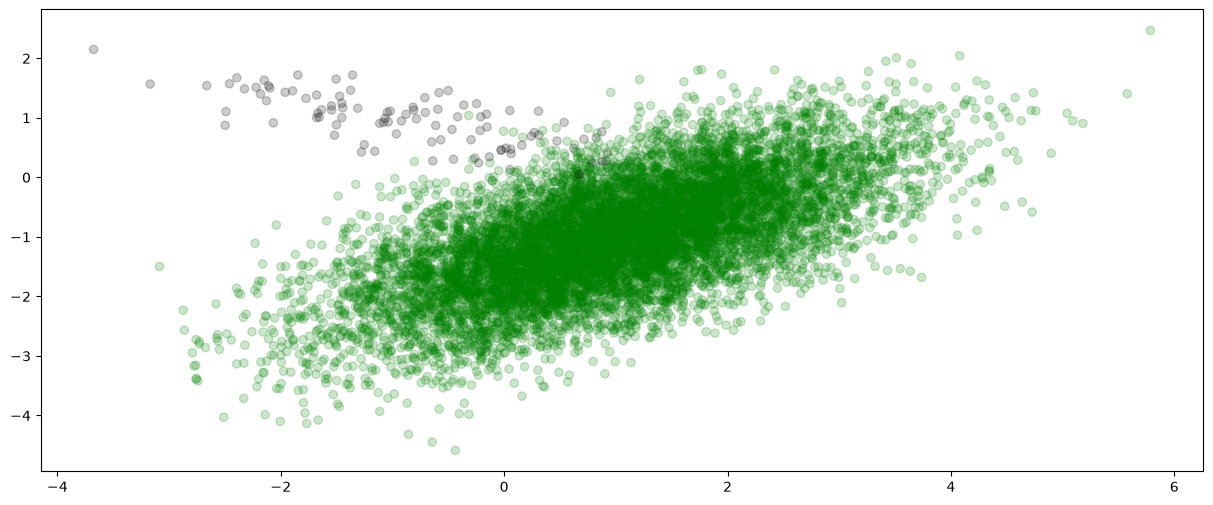

In [101]:
import matplotlib.pyplot as plt 
import numpy as np
colors=np.where(y==1,'k','g')
plt.figure(figsize=(15,6))
plt.scatter(X[:,0],X[:,1],c=colors,alpha=0.2)
plt.show()